# Subduction Rate

## Notes on Subduction Rate Frameworks

### Eulerian Framework

The traditional Eulerian subduction rate formulation:

$$
S_{total} = \frac{-\partial h}{\partial t} + w(h) - \bar{u} \cdot \nabla h
$$

**Term Definitions:**
- $S_{total}$ = Total subduction rate (m/s)
- $\frac{-\partial h}{\partial t}$ = Seasonal term (mixed layer shoaling)
- $w(h)$ = Vertical velocity at the mixed layer base  
- $\bar{u} \cdot \nabla h$ = Lateral induction using **depth-averaged** mixed layer velocity

### Quasi-Lagrangian Framework

Modified formulation using velocities at the mixed layer base:

$$
S_{total} = \frac{-\partial h}{\partial t} + w(h) - u_h \cdot \nabla h
$$

**Key Modification:**
- $u_h$ = Horizontal velocity **at** the mixed layer base
- All terms evaluated following water parcels as they cross the mixed layer base

### Physical Interpretation

In the quasi-Lagrangian framework, we calculate what happens to **water parcels exactly as they cross the mixed layer base**:

- **`u_at_mld_base`, `v_at_mld_base`**: Horizontal velocity of parcels **as they leave** the mixed layer
- **`w_at_mld_base`**: Vertical velocity of parcels **as they leave** the mixed layer  
- **`lateral_induction_ql`**: Subduction due to parcels moving **across** MLD gradients
- **`seasonal_term_mps`**: Subduction due to mixed layer base moving **relative to** parcels

### Key Advantages of Quasi-Lagrangian Framework
- **More physically accurate** for tracking water mass transformation
- **Better represents** the actual fate of water parcels leaving mixed layer
- **Eliminates assumption** of vertically uniform velocity in mixed layer
- **More consistent** with particle tracking studies

### Import functions

In [2]:
import pop_tools
import xarray as xr
import numpy as np
import cftime
import xesmf as xe
import cmocean
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon
import cartopy.crs as ccrs
from scipy.signal import coherence, csd
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks
from scipy.stats import linregress
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.ticker as ticker
import scipy.signal as signal
from scipy import stats

import warnings
warnings.filterwarnings('ignore')  # Add this at the top of your script

In [3]:
import processing_utils as proc_utils
import cesm2_lens_utils
import analysis_funcs as afuncs

#### Functions

In [3]:
def clean_dataset(da):
    """Remove conflicting coordinates and add missing dimension coordinates"""
    da_clean = da.copy()
    
    # Remove conflicting coordinates
    coords_to_remove = ['ULONG', 'ULAT', 'TLONG', 'TLAT']
    for coord in coords_to_remove:
        if coord in da_clean.coords:
            da_clean = da_clean.reset_coords(coord, drop=True)
    
    # Add missing dimension coordinates if they don't exist
    if 'nlat' not in da_clean.coords and 'nlat' in da_clean.dims:
        da_clean.coords['nlat'] = np.arange(da_clean.sizes['nlat'])
    if 'nlon' not in da_clean.coords and 'nlon' in da_clean.dims:
        da_clean.coords['nlon'] = np.arange(da_clean.sizes['nlon'])
    
    return da_clean

In [4]:
def bandpass_8years_plus(ts, sampling_freq=1, high_cutoff=1/8):
    """
    Bandpass filter for periods 8 years and longer
    high_cutoff: 1/8 years = 0.125 cycles/year (8-year period)
    """
    nyquist = sampling_freq / 2
    normal_cutoff = high_cutoff / nyquist
    
    # Design bandpass filter (lowpass effectively)
    b, a = signal.butter(4, normal_cutoff, btype='low')
    
    # Apply zero-phase filter
    filtered = signal.filtfilt(b, a, ts)
    
    return filtered

In [5]:
def normalize_neg1_to_0(ts):
    return -1 + ((ts - ts.min()) / (ts.max() - ts.min()))

In [6]:
def lead_lag_correlation(ts1, ts2, max_lag=20):
    """
    Compute lead-lag correlations between two time series
    Positive lags: ts1 leads ts2
    Negative lags: ts2 leads ts1
    """
    lags = np.arange(-max_lag, max_lag + 1)
    correlations = []
    p_values = []
    
    for lag in lags:
        if lag > 0:
            # ts1 leads ts2
            x = ts1[lag:]
            y = ts2[:-lag]
        elif lag < 0:
            # ts2 leads ts1
            x = ts1[:lag]
            y = ts2[-lag:]
        else:
            # Zero lag
            x = ts1
            y = ts2
        
        if len(x) > 2:  # Need at least 3 points for correlation
            corr, pval = stats.pearsonr(x, y)
            correlations.append(corr)
            p_values.append(pval)
        else:
            correlations.append(np.nan)
            p_values.append(np.nan)
    
    return lags, np.array(correlations), np.array(p_values)

In [7]:
def print_best_correlation(name, lags, corrs, pvals):
    if not np.all(np.isnan(corrs)):
        best_idx = np.nanargmax(np.abs(corrs))
        best_lag = lags[best_idx]
        best_corr = corrs[best_idx]
        best_pval = pvals[best_idx]
        significance = "*" if best_pval < 0.05 else ""
        print(f"{name:<30} {best_lag:<10} {best_corr:>7.3f}{significance:<3} {best_pval:>8.4f}")

In [8]:
def polynomial_regression_plot(x_data, y_data, degree=2, x_label='X Variable', y_label='Y Variable', 
                             title='Polynomial Regression', color='purple', lag_text=''):
    """
    Perform polynomial regression and create a scatter plot with fitted curve.
    
    Parameters:
    x_data: array-like, independent variable
    y_data: array-like, dependent variable  
    degree: int, degree of polynomial (default=2)
    x_label: str, label for x-axis
    y_label: str, label for y-axis
    title: str, plot title
    color: str, color for scatter points
    lag_text: str, text to include about lag in title
    """
    # Perform polynomial regression
    coefficients = np.polyfit(x_data, y_data, degree)
    polynomial = np.poly1d(coefficients)
    
    # Generate fitted curve
    x_fit = np.linspace(x_data.min(), x_data.max(), 100)
    y_fit = polynomial(x_fit)
    
    # Calculate R-squared
    y_pred = polynomial(x_data)
    ss_res = np.sum((y_data - y_pred) ** 2)
    ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    
    # Create equation string
    equation_parts = []
    for i, coef in enumerate(coefficients):
        power = len(coefficients) - i - 1
        if power == 0:
            equation_parts.append(f'{coef:.2e}')
        elif power == 1:
            equation_parts.append(f'{coef:.2e}x')
        else:
            equation_parts.append(f'{coef:.2e}x^{power}')
    equation = ' + '.join(equation_parts)
    
    # Create plot
    plt.figure(figsize=(5, 4))
    plt.scatter(x_data, y_data, color=color, s=60, alpha=0.7)
    plt.plot(x_fit, y_fit, 'red', linewidth=3, 
             label=f'Polynomial fit (degree {degree})')
    plt.xlabel(x_label, fontsize=12, fontweight='bold')
    plt.ylabel(y_label, fontsize=12, fontweight='bold')
    
    # Build title with lag information if provided
    full_title = f'{title}\n(Degree {degree}'
    if lag_text:
        full_title += f', {lag_text}'
    full_title += ')'
    plt.title(full_title, fontsize=12, fontweight='bold')
    
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Print results
    print("POLYNOMIAL REGRESSION RESULTS:")
    print("=" * 50)
    print(f"Degree: {degree}")
    print(f"Equation: y = {equation}")
    print(f"R-squared: {r_squared:.3f}")
    print(f"Coefficients: {coefficients}")
    print()
    
    return coefficients, r_squared, equation

## Process data

## LENS

In [4]:
ENS_MEMB = 49

In [5]:
%%time
COMP = 'ocn'
VAR = 'HMXL'
ens_ind = ENS_MEMB
DIRECTORY = f'/glade/campaign/cgd/cesm/CESM2-LE/{COMP}/proc/tseries/month_1/{VAR}/'
ds_var_hist_var, ds_var_fut_var = cesm2_lens_utils.get_ds_var(
    directory=DIRECTORY, var=VAR, comp=COMP, index_hist = ENS_MEMB)

HMXL = afuncs.ocn_var_ens(ENS_MEMB, 'HMXL')[:240,72:303,140:293].compute()

DXT = ds_var_hist_var.DXT.sel(time=slice('1958-01', '2015-01'))[:240,72:303,140:293] #[:,72:225,171:293] #[:,72:303,140:293]
DYT = ds_var_hist_var.DYT.sel(time=slice('1958-01', '2015-01'))[:240,72:303,140:293]
WVEL = afuncs.ocn_var_ens(ENS_MEMB, 'WVEL')[:240,:25,72:303,140:293]
UVEL = afuncs.ocn_var_ens(ENS_MEMB, 'UVEL')[:240,:25,72:303,140:293]
VVEL = afuncs.ocn_var_ens(ENS_MEMB, 'VVEL')[:240,:25,72:303,140:293]

CPU times: user 8.41 s, sys: 1.01 s, total: 9.42 s
Wall time: 27.8 s


In [6]:
HMXL

<xarray.DataArray 'HMXL' (time: 240, nlat: 231, nlon: 153)>
array([[[ 3474.4075,  3668.758 ,  3770.6614, ...,        nan,
                nan,        nan],
        [ 3308.8103,  3456.8633,  3614.926 , ...,        nan,
                nan,        nan],
        [ 3245.0723,  3355.2852,  3523.671 , ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,  4895.542 ,
          5555.792 ,  6898.5156],
        [       nan,        nan,        nan, ...,  4840.1274,
          5334.5723,  6029.883 ],
        [       nan,        nan,        nan, ...,  1293.9504,
          4548.8774,  5328.21  ]],

       [[ 3493.5244,  3467.3328,  3466.0256, ...,        nan,
                nan,        nan],
        [ 3415.727 ,  3375.4006,  3367.952 , ...,        nan,
                nan,        nan],
        [ 3365.1318,  3361.5867,  3365.4019, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,  4346.528 ,
          4758.215 ,  5228.306 ],
        [       nan,        nan,        nan, ...,  4732.3755,
          4785.396 ,  5129.503 ],
        [       nan,        nan,        nan, ...,  1188.1073,
          4497.5776,  5196.441 ]],

       [[ 3642.4246,  3697.7944,  3715.8855, ...,        nan,
                nan,        nan],
        [ 3463.7144,  3491.9324,  3549.629 , ...,        nan,
                nan,        nan],
        [ 3486.9028,  3469.723 ,  3472.791 , ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,  5043.728 ,
          5907.56  ,  6984.343 ],
        [       nan,        nan,        nan, ...,  5269.421 ,
          5928.256 ,  6821.4434],
        [       nan,        nan,        nan, ...,  1390.5919,
          3233.5193,  6526.896 ]]], dtype=float32)
Coordinates:
    ULONG    (nlat, nlon) float64 118.6 119.8 120.9 122.0 ... 288.1 289.2 290.3
    ULAT     (nlat, nlon) float64 -40.49 -40.49 -40.49 ... 40.91 40.86 40.82
    TLONG    (nlat, nlon) float64 118.1 119.2 120.3 121.4 ... 287.6 288.7 289.8
    TLAT     (nlat, nlon) float64 -40.76 -40.76 -40.76 ... 40.72 40.67 40.62
  * time     (time) object 1958-01-01 00:00:00 ... 1977-12-01 00:00:00
Dimensions without coordinates: nlat, nlon
Attributes:
    long_name:     Mixed-Layer Depth
    units:         centimeter
    grid_loc:      2110
    cell_methods:  time: mean

## FOSI

In [11]:
#### FOSI set up
firstyear = 1959
lastyear = 2015
grid = pop_tools.get_grid('POP_gx1v7')
mask = xr.where((grid['REGION_MASK']>0) & (grid['REGION_MASK']<9), 1, np.nan)
fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
fosi_montime_vals = [cftime.DatetimeNoLeap(1958+year, 1+month, 15) for year in range(63) for month in range(12)]

In [50]:
field = 'HMXL'
fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'
HMXL = xr.open_dataset(fpath+fname)[field][:,72:303,140:293].compute()
HMXL['time'] = fosi_montime_vals

DXT = xr.open_dataset(fpath+fname).DXT[72:303,140:293].compute()
DYT = xr.open_dataset(fpath+fname).DXT[72:303,140:293].compute()

In [35]:
field = 'WVEL'
fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'
WVEL = xr.open_dataset(fpath+fname)[field][:,:25,72:303,140:293].compute()
WVEL['time'] = fosi_montime_vals

field = 'UVEL'
fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'
UVEL = xr.open_dataset(fpath+fname)[field][:,:25,72:303,140:293].compute()
UVEL['time'] = fosi_montime_vals

field = 'VVEL'
fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'
VVEL = xr.open_dataset(fpath+fname)[field][:,:25,72:303,140:293].compute()
VVEL['time'] = fosi_montime_vals

## Calculation

In [134]:
DYT_m = (DYT / 100).compute()
DXT_m = (DXT / 100).compute()
HMXL_m = (HMXL/100).compute()

WVEL_ms = WVEL/100 # cm/s -> m/s
UVEL_ms = UVEL/100 # cm/s -> m/s
VVEL_ms = VVEL/100 # cm/s -> m/s

## Calculate the three subduction components

In [135]:
SEC_PER_MONTH = 365.25/12 * 24 * 3600  # ≈ 2,629,800 seconds

In [136]:
%%time
seasonal_term = -HMXL_m.diff('time', n=1)  # (m/month)
seasonal_term_mps = (seasonal_term/SEC_PER_MONTH).compute()

CPU times: user 10.3 ms, sys: 7.02 ms, total: 17.3 ms
Wall time: 23 ms


In [137]:
%%time
dh_dx = HMXL_m.differentiate('nlon') / DXT_m
dh_dy = HMXL_m.differentiate('nlat') / DYT_m

CPU times: user 27.5 ms, sys: 23.9 ms, total: 51.4 ms
Wall time: 68.8 ms


In [138]:
%%time
WVEL_renamed = WVEL_ms.rename({'z_w_top': 'depth'}).compute()
UVEL_renamed = UVEL_ms.rename({'z_t': 'depth'}).compute()
VVEL_renamed = VVEL_ms.rename({'z_t': 'depth'}).compute()
# 5 min 30 s

CPU times: user 37.8 s, sys: 1.3 s, total: 39.1 s
Wall time: 2min 19s


In [139]:
%%time
WVEL_clean = clean_dataset(WVEL_ms)
UVEL_clean = clean_dataset(UVEL_ms)
VVEL_clean = clean_dataset(VVEL_ms)
HMXL_clean = clean_dataset(HMXL)

CPU times: user 81.3 ms, sys: 3.85 ms, total: 85.2 ms
Wall time: 120 ms


In [140]:
%%time
w_at_mld_base = WVEL_clean.interp(z_w_top=HMXL_clean, method='linear').compute() # 3 min 30 s

CPU times: user 25.1 s, sys: 1.68 s, total: 26.8 s
Wall time: 1min


In [141]:
%%time
u_at_mld_base = UVEL_clean.interp(z_t=HMXL_clean, method='linear').compute()

CPU times: user 24.7 s, sys: 1.64 s, total: 26.4 s
Wall time: 1min 1s


In [142]:
%%time
v_at_mld_base = VVEL_clean.interp(z_t=HMXL_clean, method='linear').compute()

CPU times: user 24.9 s, sys: 1.64 s, total: 26.5 s
Wall time: 1min 4s


In [143]:
%%time
lateral_induction = - (u_at_mld_base * dh_dx + v_at_mld_base * dh_dy)  # [m/s]

CPU times: user 19.8 ms, sys: 23.6 ms, total: 43.4 ms
Wall time: 45.7 ms


In [68]:
### --------- SCRATCH (INCLUDE PREVIOUS METHOD OF INTERPOLATION AND EULERIAN FRAMEWORK)
# WVEL_renamed = WVEL_ms.rename({'z_w_top': 'depth'}).compute()
# UVEL_renamed = UVEL_ms.rename({'z_t': 'depth'}).compute()
# VVEL_renamed = VVEL_ms.rename({'z_t': 'depth'}).compute()

# # Clean all datasets
# WVEL_clean = clean_dataset(WVEL_ms)
# UVEL_clean = clean_dataset(UVEL_ms)
# VVEL_clean = clean_dataset(VVEL_ms)
# HMXL_clean = clean_dataset(HMXL)

# print("After cleaning:")
# print(f"WVEL_clean coords: {list(WVEL_clean.coords)}")
# print(f"UVEL_clean coords: {list(UVEL_clean.coords)}")
# print(f"HMXL_clean coords: {list(HMXL_clean.coords)}")

# w_at_mld_base = WVEL_clean.interp(z_w_top=HMXL_clean, method='linear').compute()
# u_at_mld_base = UVEL_clean.interp(z_t=HMXL_clean, method='linear').compute()
# v_at_mld_base = VVEL_clean.interp(z_t=HMXL_clean, method='linear').compute()

### -------- In the Eulerian (takes up a lot of memory)
# interpolated_UVEL = UVEL_ms[:,:25,:,25:].interp(z_t=np.linspace(0,26000, 131), method='linear')
# interpolated_VVEL = VVEL_ms[:,:25,:,25:].interp(z_t=np.linspace(0,26000, 131), method='linear')

# UVEL_renamed = interpolated_UVEL.rename({'z_t': 'depth'})
# VVEL_renamed = interpolated_VVEL.rename({'z_t': 'depth'})

# u_avg = UVEL_renamed.where(UVEL_renamed.depth <= HMXL[:,:,:]).mean('depth')
# v_avg = VVEL_renamed.where(VVEL_renamed.depth <= HMXL[:,:,:]).mean('depth')

## Total subduction rate

In [144]:
%%time
t_subduction_r = w_at_mld_base + lateral_induction + seasonal_term_mps
t_subduction_r = t_subduction_r.compute()

CPU times: user 15.6 ms, sys: 27.9 ms, total: 43.5 ms
Wall time: 43.7 ms


In [146]:
filepath = '/glade/derecho/scratch/cassiacai/total_subduction_rate_{}.nc'.format(ENS_MEMB)
print(filepath)

/glade/derecho/scratch/cassiacai/total_subduction_rate_49.nc


In [147]:
t_subduction_r.to_netcdf(filepath)

In [28]:
# t_subduction_r.to_netcdf('/glade/derecho/scratch/cassiacai/total_subduction_rate_0.nc')
# t_subduction_r.to_netcdf('/glade/derecho/scratch/cassiacai/total_subduction_rate_98.nc')

In [64]:
# t_subduction_r.to_netcdf('/glade/derecho/scratch/cassiacai/fosi_total_subduction_rate.nc')

## Analysis

In [9]:
def regrid_SMYLE(ds, glat=1, glon=1): # from Jacob's notebook
    """
    Inputs:
        ds: xr.DataArray with coordinates that include TLAT and TLONG
    Returns:
        Regridded xr.DataArray with coordinates lat and lon
    """
    ds = ds.rename(({'ULONG': 'lon', 'ULAT': 'lat'}))
    ds_out = xe.util.grid_global(glon, glat)
    regridder = xe.Regridder(ds, ds_out, 'bilinear', periodic=True)
    regridded = regridder(ds)
    new_coords = regridded.assign_coords({'y': regridded.lat[:, 0].values, 'x': regridded.lon[0].values})
    return new_coords.drop_vars(['lat', 'lon']).rename({'x': 'lon', 'y': 'lat'})

In [10]:
ensemble_members = [0, 65,  32, 85, 61, 90, 80, 68, 73, 49]

## Subduction

In [12]:
file_paths = [f'/glade/derecho/scratch/cassiacai/total_subduction_rate_{i}.nc' for i in ensemble_members]
ds = xr.open_mfdataset(file_paths, combine='nested', concat_dim='ensemble', parallel=True)
ds.coords['ensemble'] = range(10)
total_subduction = ds['__xarray_dataarray_variable__'].compute()

In [13]:
lens_subduction_mean = total_subduction.isel(time=slice(0, 240)).mean(dim=('time','ensemble'))

In [14]:
fosi_t_subduction_r = xr.open_dataset('/glade/derecho/scratch/cassiacai/fosi_total_subduction_rate.nc').__xarray_dataarray_variable__

In [15]:
fosi_subduction_mean = fosi_t_subduction_r.isel(time=slice(0, 240)).mean(dim='time')

### Subduction Rate - Spatial plots

In [55]:
lens_subduction_mean_masked = lens_subduction_mean.where((lens_subduction_mean.nlat < 107) | (lens_subduction_mean.nlat > 123))
fosi_subduction_mean_masked = fosi_subduction_mean.where((fosi_subduction_mean.nlat < 107) | (fosi_subduction_mean.nlat > 123))

In [411]:
diff = np.absolute(lens_subduction_mean) - np.absolute(fosi_subduction_mean)
# diff = lens_subduction_mean_masked - fosi_subduction_mean_masked

In [412]:
# Processing transport at depth
diff_ULONG = diff.assign_coords(
    ULONG=(('nlat', 'nlon'), 
           lens_subduction_mean['ULONG'].values))

diff_ULONG_LAT = diff_ULONG.assign_coords(
    ULAT=(('nlat', 'nlon'), 
           lens_subduction_mean['ULAT'].values))

In [414]:
diff_1deg_wzeros = regrid_SMYLE(diff_ULONG_LAT)
diff_1deg_var = diff_1deg_wzeros.where(diff_1deg_wzeros!=0, np.nan)

regridder = xe.Regridder(diff_1deg_var, CESMLENS_var[:,:], 'nearest_s2d', periodic=True)
regridded_diff = regridder(diff_1deg_var)


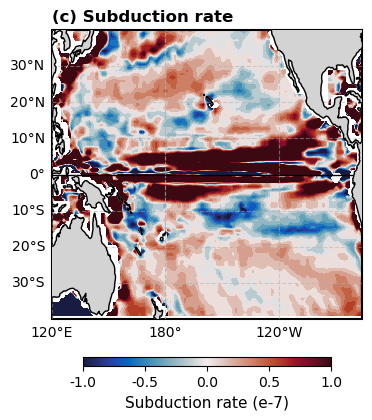

In [415]:
fig, ax = plt.subplots(figsize=(4, 5),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})

####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -40, 40], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

# # #### CONTOURF AND CONTOUR
# contourf_plot = regridded_diff.plot.contourf(
#     x='lon', y='lat', cmap='PRGn', add_colorbar=False, transform=ccrs.PlateCarree(),
#     vmin=-0.08e-5, vmax=0.08e-5, levels=9, alpha=1)

contourf_plot = regridded_diff.plot.contourf(
    x='lon', y='lat', cmap=cmocean.cm.balance, add_colorbar=False, transform=ccrs.PlateCarree(),
    vmin=-1e-6, vmax=1e-6, levels=19, alpha=1)

#### COLORBAR
density_sm = plt.cm.ScalarMappable(cmap=cmocean.cm.balance, norm=plt.Normalize(-1e-6, 1e-6))
density_sm.set_array([])
density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
density_cbar.set_label('Subduction rate (e-7)', fontsize=11)
tick_values = np.asarray([-1, -0.5, 0, 0.5, 1])#np.arange(-8, 10, 2) 
density_cbar.set_ticks(tick_values*1e-6)
density_cbar.set_ticklabels([f'{x}' for x in tick_values]) 
density_cbar.ax.tick_params(labelsize=10)

plt.title('(c) Subduction rate', fontsize=12, fontweight='bold', zorder=12, loc='left')
plt.show()

In [79]:
regridded_diff.sel(lat=slice(-5, 5)).mean()

<xarray.DataArray ()>
array(3.95022159e-07)

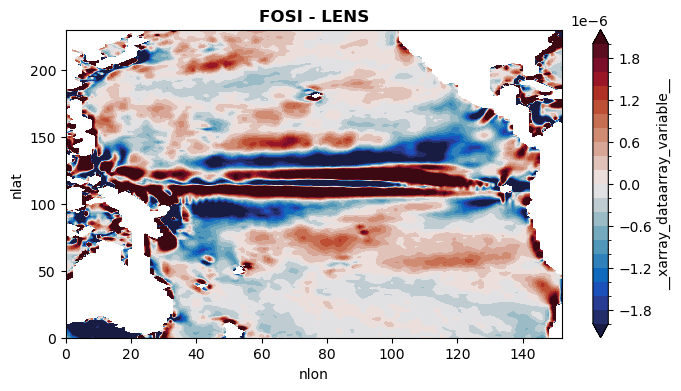

In [25]:
plt.figure(figsize=(8,4))
cf = diff.plot.contourf(
    vmin=-0.2e-5, vmax=0.2e-5, cmap=cmocean.cm.balance, levels=21)
# contours = diff.plot.contour(
#     vmin=-0.2e-5, vmax=0, levels=9, colors='black', linewidths=1, alpha=0.7)
# contours = diff.plot.contour(
#     vmin=0.2e-5, vmax=0.2e-5, levels=2, colors='red', linewidths=1, alpha=0.7)
plt.title('FOSI - LENS', fontsize=12, fontweight='bold')
plt.show()

In [70]:
t_subduction_r_masked = t_subduction_r.where((t_subduction_r.nlat < 107) | (t_subduction_r.nlat > 123))

In [128]:
t_subduction_r_masked_98 = t_subduction_r_98.where((t_subduction_r_98.nlat < 107) | (t_subduction_r_98.nlat > 123))

In [73]:
fosi_t_subduction_r_masked = fosi_t_subduction_r.where((fosi_t_subduction_r.nlat < 107) | (fosi_t_subduction_r.nlat > 123))

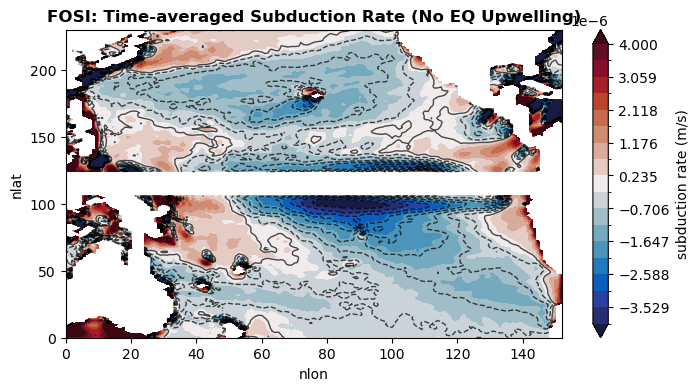

In [79]:
plt.figure(figsize=(8,4))
cf = fosi_t_subduction_r_masked.mean(dim='time').plot.contourf(
    vmin=-0.4e-5, vmax=0.4e-5, cmap=cmocean.cm.balance, levels=18,
    add_colorbar=False)  # Remove default colorbar
cbar = plt.colorbar(cf)
cbar.set_label('subduction rate (m/s)', fontsize=10)

contours = fosi_t_subduction_r_masked.mean(dim='time').plot.contour(
    vmin=-0.4e-5, vmax=0, levels=9, colors='black', linewidths=1, alpha=0.7)
plt.title('FOSI: Time-averaged Subduction Rate (No EQ Upwelling)', fontsize=12, fontweight='bold')
plt.show()

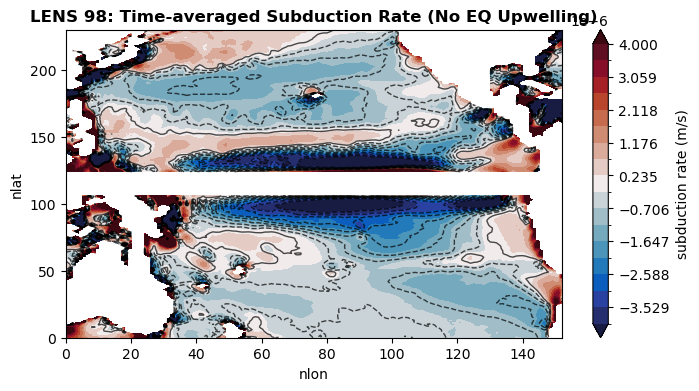

In [129]:
plt.figure(figsize=(8,4))
cf = t_subduction_r_masked_98.mean(dim='time').plot.contourf(
    vmin=-0.4e-5, vmax=0.4e-5, cmap=cmocean.cm.balance, levels=18,
    add_colorbar=False)  # Remove default colorbar
cbar = plt.colorbar(cf)
cbar.set_label('subduction rate (m/s)', fontsize=10)

contours = t_subduction_r_masked_98.mean(dim='time').plot.contour(
    vmin=-0.4e-5, vmax=0, levels=9, colors='black', linewidths=1, alpha=0.7)
plt.title('LENS 98: Time-averaged Subduction Rate (No EQ Upwelling)', fontsize=12, fontweight='bold')
plt.show()

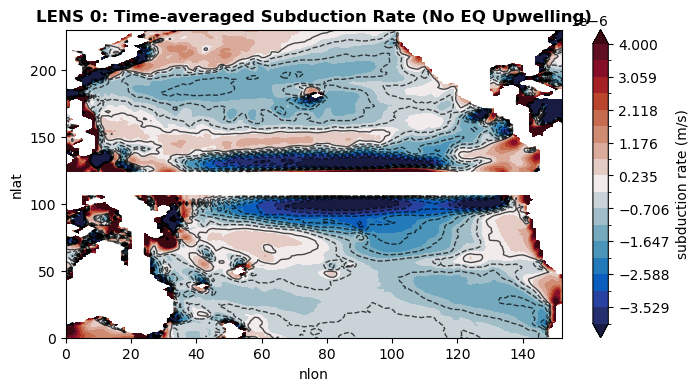

In [78]:
plt.figure(figsize=(8,4))
cf = t_subduction_r_masked.mean(dim='time').plot.contourf(
    vmin=-0.4e-5, vmax=0.4e-5, cmap=cmocean.cm.balance, levels=18,
    add_colorbar=False)  # Remove default colorbar
cbar = plt.colorbar(cf)
cbar.set_label('subduction rate (m/s)', fontsize=10)

contours = t_subduction_r_masked.mean(dim='time').plot.contour(
    vmin=-0.4e-5, vmax=0, levels=9, colors='black', linewidths=1, alpha=0.7)
plt.title('LENS 0: Time-averaged Subduction Rate (No EQ Upwelling)', fontsize=12, fontweight='bold')
plt.show()

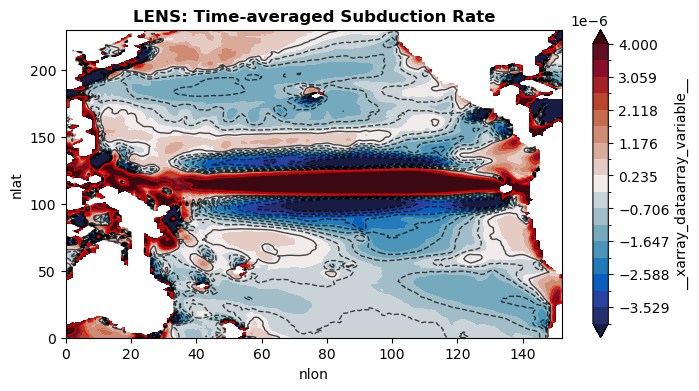

In [17]:
plt.figure(figsize=(8,4))
cf = lens_subduction_mean.plot.contourf(
    vmin=-0.4e-5, vmax=0.4e-5, cmap=cmocean.cm.balance, levels=18)
contours = lens_subduction_mean.plot.contour(
    vmin=-0.4e-5, vmax=0, levels=9, colors='black', linewidths=1, alpha=0.7)
contours = lens_subduction_mean.plot.contour(
    vmin=0.2e-5, vmax=0.4e-5, levels=2, colors='red', linewidths=1, alpha=0.7)
plt.title('LENS: Time-averaged Subduction Rate', fontsize=12, fontweight='bold')
plt.show()

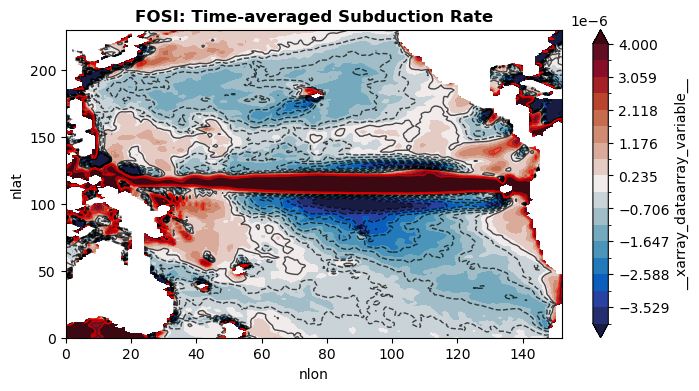

In [18]:
plt.figure(figsize=(8,4))
cf = fosi_subduction_mean.plot.contourf(
    vmin=-0.4e-5, vmax=0.4e-5, cmap=cmocean.cm.balance, levels=18)
contours = fosi_subduction_mean.plot.contour(
    vmin=-0.4e-5, vmax=0, levels=9, colors='black', linewidths=1, alpha=0.7)
contours = fosi_subduction_mean.plot.contour(
    vmin=0.2e-5, vmax=0.4e-5, levels=2, colors='red', linewidths=1, alpha=0.7)
plt.title('FOSI: Time-averaged Subduction Rate', fontsize=12, fontweight='bold')
plt.show()

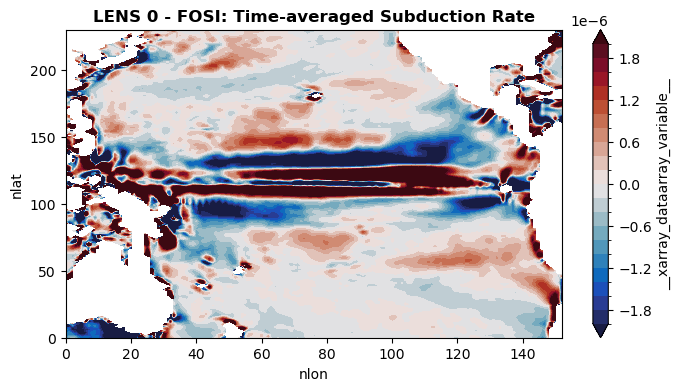

In [115]:
plt.figure(figsize=(8,4))
diff_2 = t_subduction_r_0.mean(dim='time') - fosi_t_subduction_r.mean(dim='time')
cf = diff_2.plot.contourf(
    vmin=-0.2e-5, vmax=0.2e-5, cmap=cmocean.cm.balance, levels=21)
# contours = diff.mean(dim='time').plot.contour(
#     vmin=-0.4e-5, vmax=0, levels=9, colors='black', linewidths=1, alpha=0.7)
# contours = diff.mean(dim='time').plot.contour(
#     vmin=0.2e-5, vmax=0.4e-5, levels=2, colors='red', linewidths=1, alpha=0.7)
plt.title('LENS 0 - FOSI: Time-averaged Subduction Rate', fontsize=12, fontweight='bold')
plt.show()

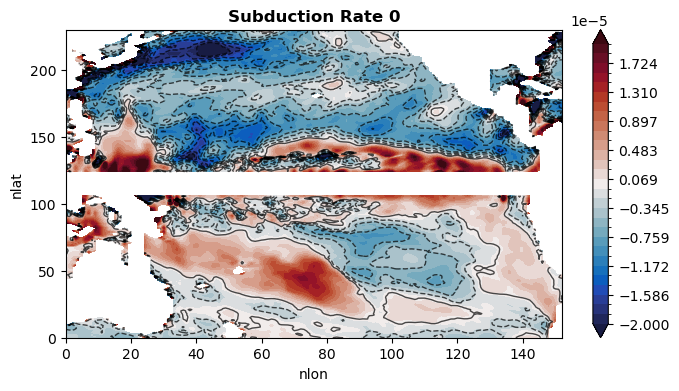

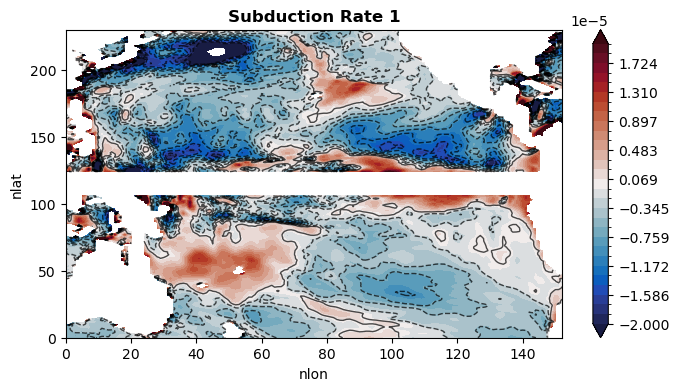

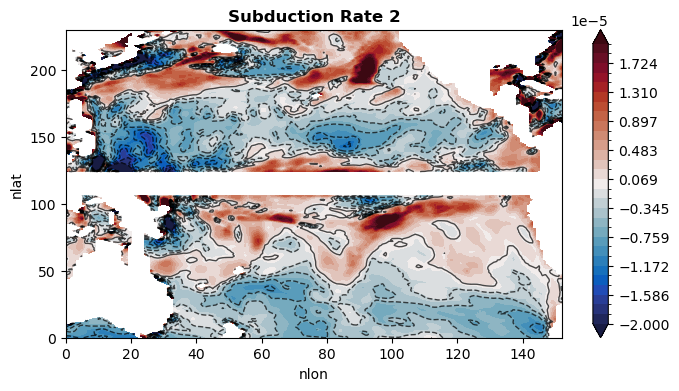

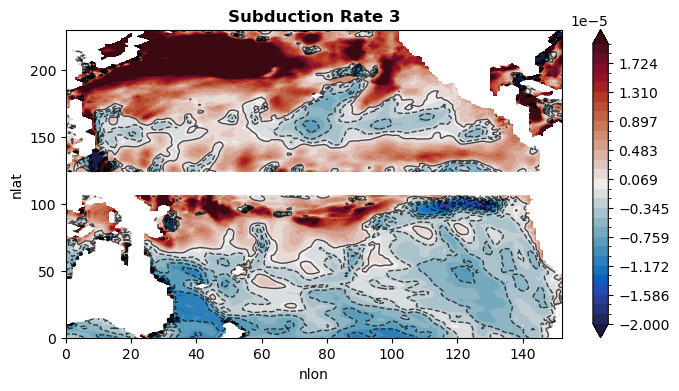

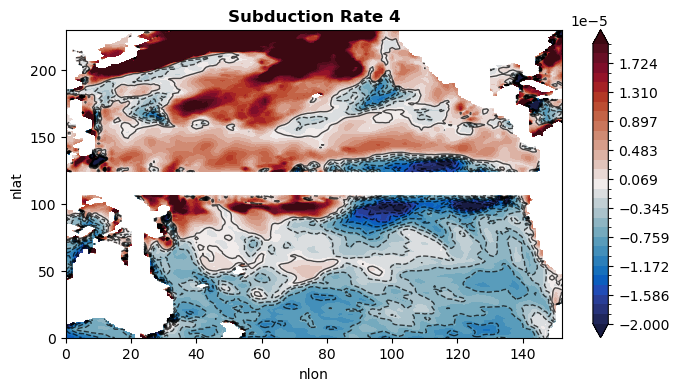

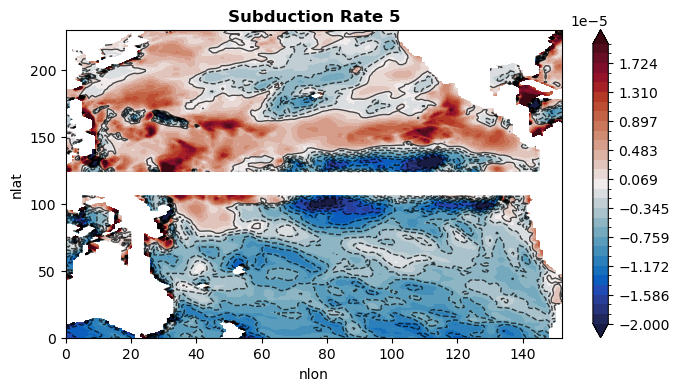

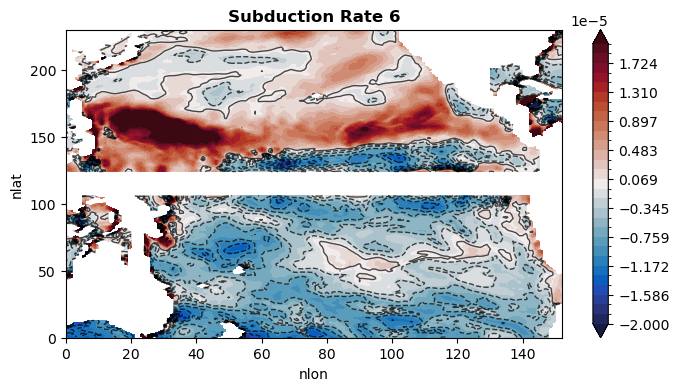

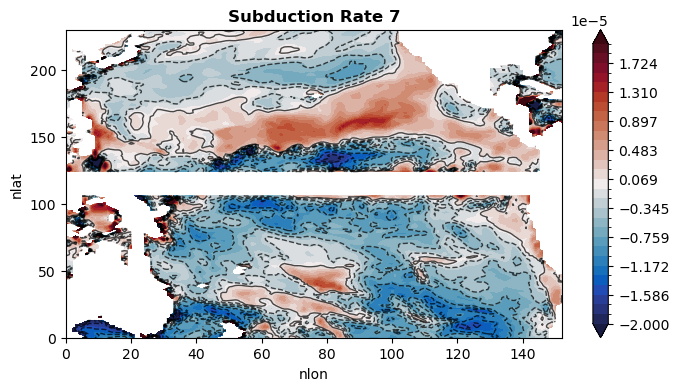

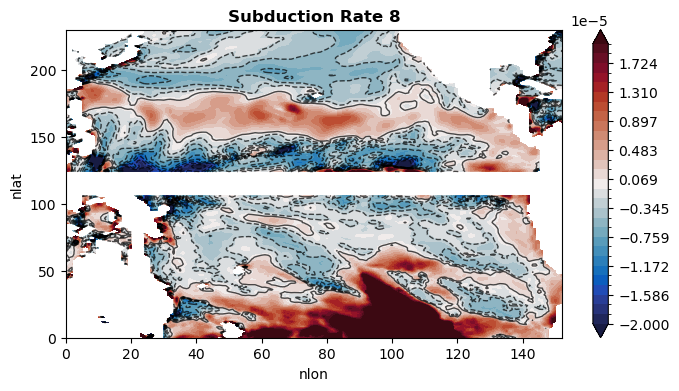

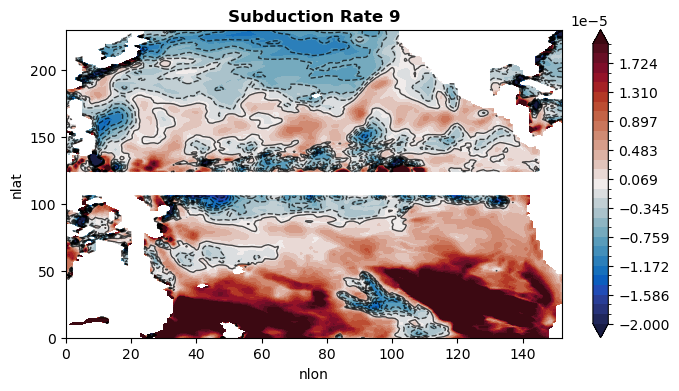

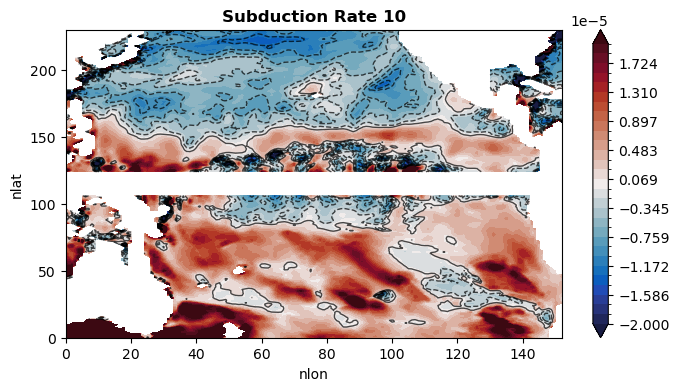

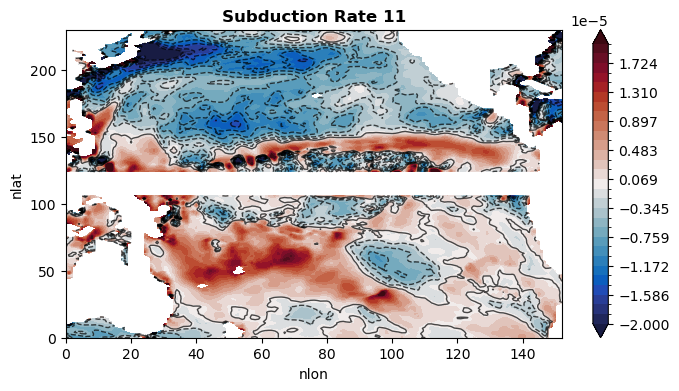

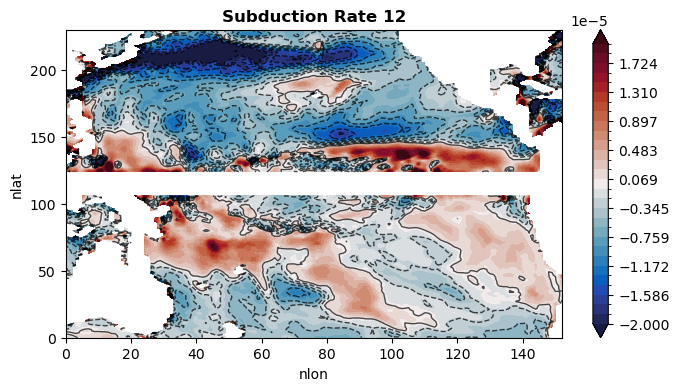

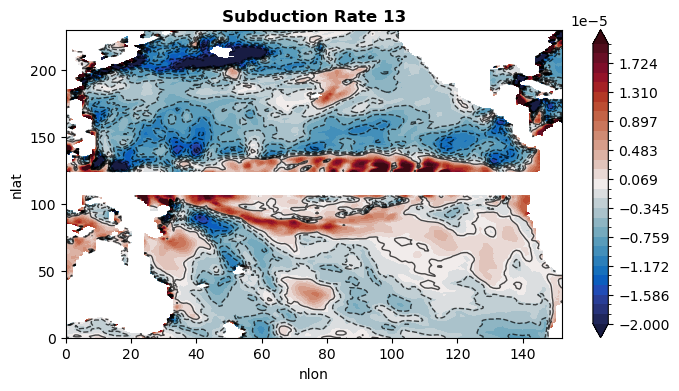

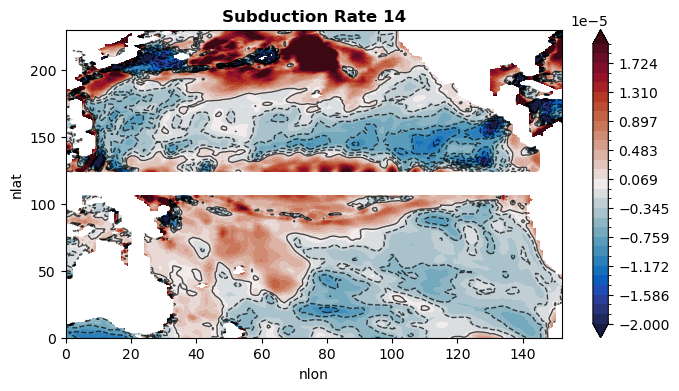

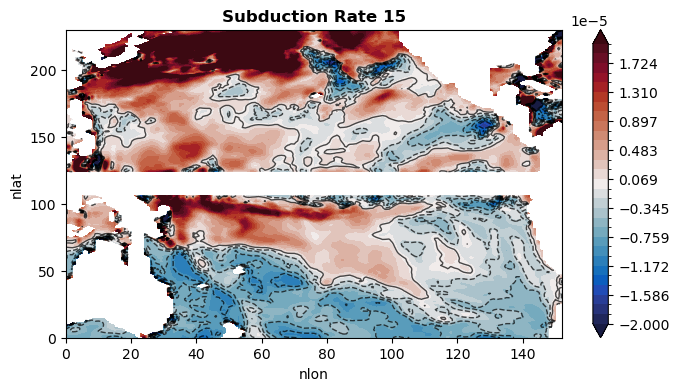

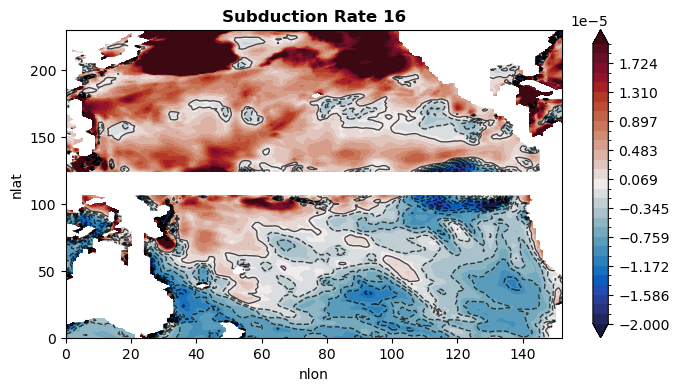

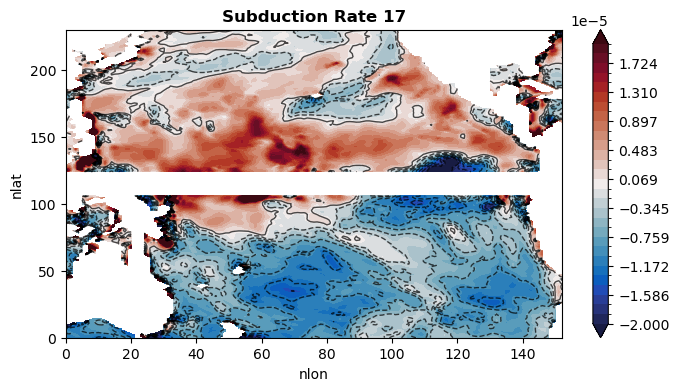

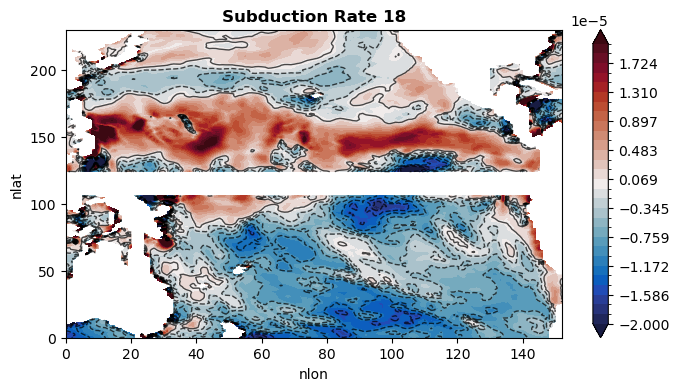

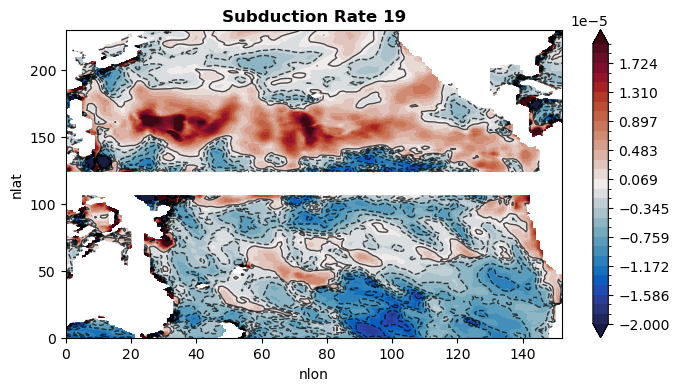

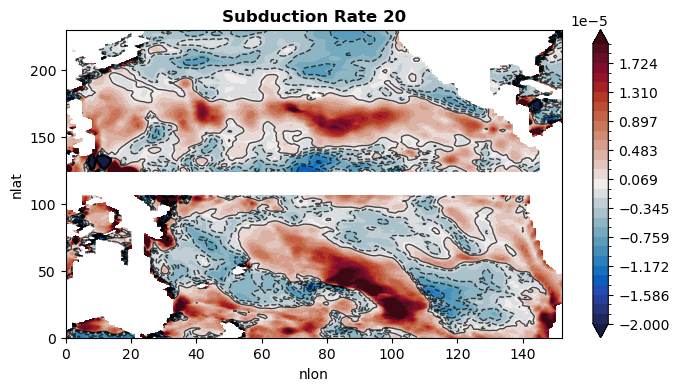

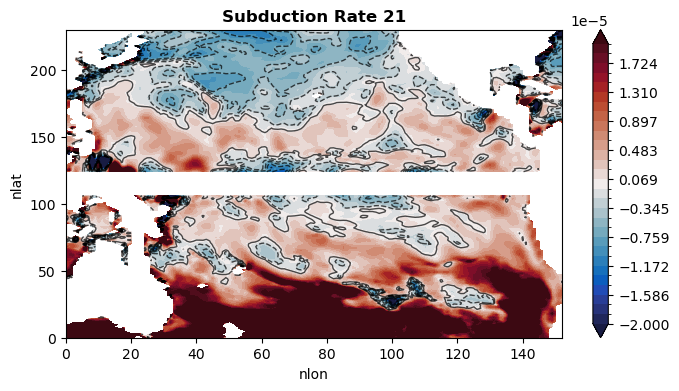

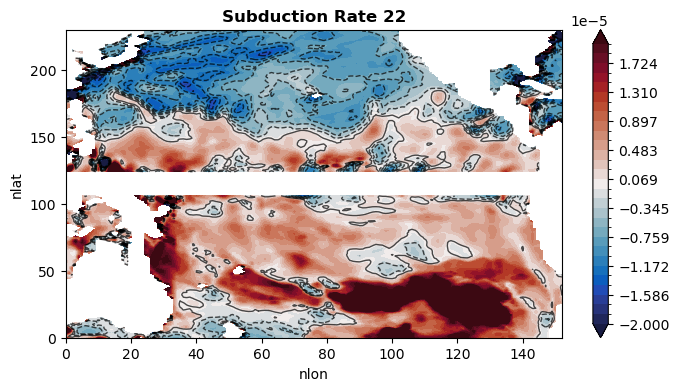

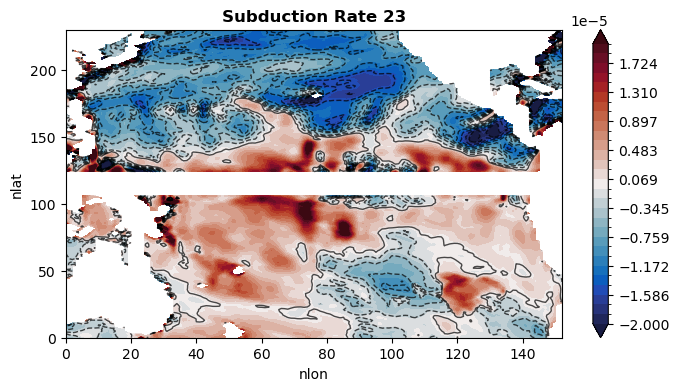

In [222]:
for timestep in range(24):
    plt.figure(figsize=(8,4))
    cf = t_subduction_r_masked[timestep,:,:].plot.contourf(
        vmin=-2.0e-5, vmax=2.0e-5, cmap=cmocean.cm.balance, levels=30)
    contours = t_subduction_r_masked[timestep,:,:].plot.contour(
        vmin=-2.0e-5, vmax=0, levels=9, colors='black', linewidths=1, alpha=0.7)
    plt.title('Subduction Rate {}'.format(timestep), fontsize=12, fontweight='bold')
    plt.show()

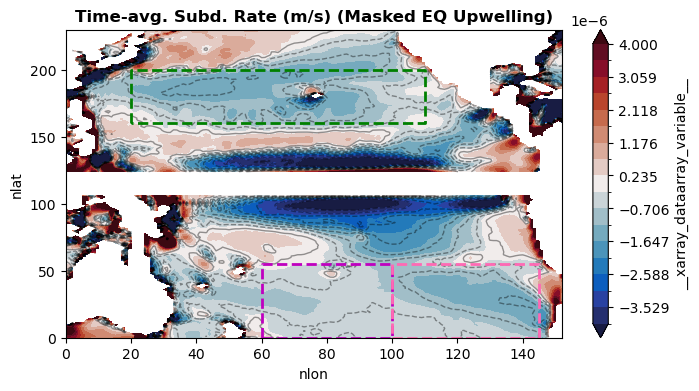

In [15]:
plt.figure(figsize=(8,4))
cf = t_subduction_r_masked.mean(dim='time').plot.contourf(
    vmin=-0.4e-5, vmax=0.4e-5, cmap=cmocean.cm.balance, levels=18)
contours = t_subduction_r_masked.mean(dim='time').plot.contour(
    vmin=-0.4e-5, vmax=0, levels=9, colors='black', linewidths=1, alpha=0.4)
plt.title('Time-avg. Subd. Rate (m/s) (Masked EQ Upwelling)', fontsize=12, fontweight='bold')
plt.plot([60, 100, 100, 60, 60], [0, 0, 55, 55, 0], 'm', linestyle='dashed', linewidth=2)
plt.plot([100, 145, 145, 100, 100], [0, 0, 55, 55, 0], 'hotpink', linestyle='dashed', linewidth=2)
plt.plot([20, 20, 110, 110, 20],[160, 200, 200, 160, 160], 'green', linestyle='dashed', linewidth=2)
plt.show()